# Post-merge feature demo — `convex-analysis-pr`

Three self-contained sections showcasing the additions since the PR #132 merge.
Each section can be run independently.

| Section | Feature |
|---------|---------|
| **A** | Exact 2D credible-set plots — no sampling, analytic boundary |
| **B** | Function-space credible sets: `ambient_ball` and `weakened_ellipsoid` |
| **C** | Exact spherical-cap integral functional |

In [19]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from pygeoinf import GaussianMeasure
from pygeoinf.hilbert_space import EuclideanSpace

%matplotlib inline

## Section A — Exact 2D credible-set plots

`Subset.plot()` now dispatches to an exact quadratic-slice renderer for `Ball` and `Ellipsoid`.
The boundary curve is derived analytically from the Cholesky factorisation — no grid, no sampling.

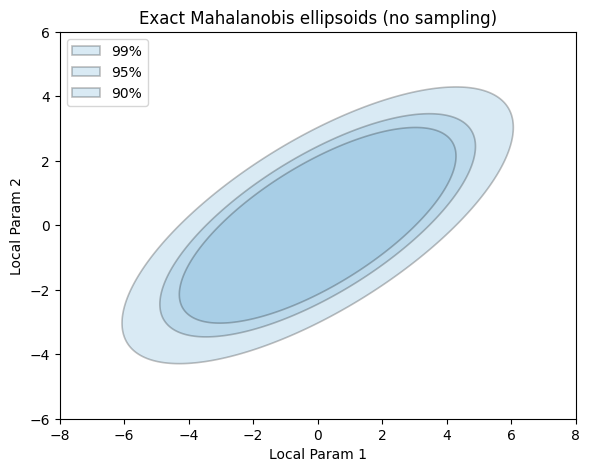

In [20]:
space = EuclideanSpace(2)
cov   = np.array([[4.0, 2.0],
                  [2.0, 2.0]])
mu    = GaussianMeasure.from_covariance_matrix(space, cov)

e90 = mu.credible_set(0.90)
e95 = mu.credible_set(0.95)
e99 = mu.credible_set(0.99)

# bounds chosen to fully contain the 99% ellipsoid
bounds = [[-8, 8], [-6, 6]]

fig, ax = plt.subplots(figsize=(6, 5))
for e, c in [(e99, "steelblue"), (e95, "cornflowerblue"), (e90, "lightblue")]:
    e.plot(ax=ax, bounds=bounds, alpha=0.25, show_plot=False)
ax.set_title("Exact Mahalanobis ellipsoids (no sampling)")
ax.set_aspect("equal")
ax.legend(["99%", "95%", "90%"], loc="upper left")
plt.tight_layout()

## Section B — Function-space credible sets

Two new `GaussianMeasure` geometries calibrated via the **weighted chi-squared** distribution of the covariance spectrum.

- **`ambient_ball`** — calibrates $\|f\|_{L^2} \le r_p$ using the full covariance spectrum.
- **`weakened_ellipsoid`** — uses $C^{-\theta}$ as the metric; $\theta=0$ matches the ambient geometry and $\theta \to 1$ approaches the Cameron-Martin boundary.

This demo uses a **heat-kernel prior** on the periodic line `pygeoinf.symmetric_space.line.Lebesgue`. Unlike the earlier flat-in-Sobolev example, this is a genuine trace-class covariance with a stable continuous limit as the Fourier truncation is refined. We still pass the exact spectral variances explicitly so `ambient_ball` and `weakened_ellipsoid` stay on the fast spectral path.

In [21]:
from pygeoinf.symmetric_space.line import Lebesgue as LineLebesgue

# Periodic L2 line on [0,1] with a heat-kernel prior.
# This is a genuine trace-class covariance family; refining kmax converges to
# the continuous heat-kernel Gaussian rather than changing the prior family.
space_1d = LineLebesgue(12)
mu_fs    = space_1d.heat_kernel_gaussian_measure(0.45)

# The invariant measure already knows its covariance eigenvalues exactly.
# Passing them explicitly keeps the credible-set calibration on the fast
# weighted-chi-square path and avoids randomized spectrum resolution.
spec = mu_fs.spectral_variances

ambient  = mu_fs.ambient_ball(0.95, spectrum=spec)
weakened = mu_fs.weakened_ellipsoid(0.95, theta=0.5, spectrum=spec)

print(f"heat-kernel trace            = {spec.sum():.6f}")
print(f"ambient_ball radius          = {ambient.radius:.4f}")
print(f"weakened_ellipsoid (θ=0.5)   = {weakened.radius:.4f}")

heat-kernel trace            = 1.007762
ambient_ball radius          = 1.9619
weakened_ellipsoid (θ=0.5)   = 1.9928


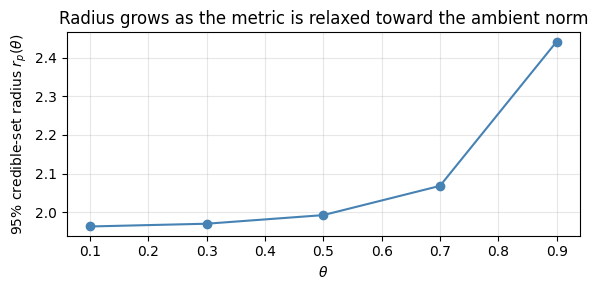

In [22]:
thetas = [0.1, 0.3, 0.5, 0.7, 0.9]
radii  = [mu_fs.weakened_ellipsoid(0.95, theta=th, spectrum=spec).radius
          for th in thetas]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(thetas, radii, "o-", color="steelblue")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"95% credible-set radius $r_p(\theta)$")
ax.set_title("Radius grows as the metric is relaxed toward the ambient norm")
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Section C — Exact spherical-cap integral

`spherical_cap_integral` and `spherical_cap_average` return `LinearForm` objects computed analytically from the spherical-harmonic expansion of the cap indicator — no quadrature grid needed.

Given any model field $f$ on the sphere, `cap_integral(f)` = $\int_C f\,dS$ and `cap_average(f)` = $|C|^{-1}\int_C f\,dS$.

In [23]:
from pygeoinf.symmetric_space.sphere import Lebesgue as SphericalLebesgue

# Earth-radius sphere; lmax=10 → dim = (lmax+1)² = 121 basis coefficients
sphere = SphericalLebesgue(10, radius=6371.0)

center         = (0.0, 0.0)        # equatorial cap (lat, lon) in degrees
angular_radius = np.radians(20.0)  # 20° angular radius

cap_integral = sphere.spherical_cap_integral(center, angular_radius)
cap_average  = sphere.spherical_cap_average(center, angular_radius)

cap_area = 2.0 * np.pi * sphere.radius**2 * (1.0 - np.cos(angular_radius))
print(f"Cap area (analytic)  = {cap_area:.3e} km²")
print(f"LinearForm dimension = {cap_integral.components.shape[0]} coefficients")

# The two forms should differ by exactly the cap area (component-wise)
ratio = cap_integral.components / cap_average.components
print(f"integral / average ratio: min={ratio.min():.6e}  max={ratio.max():.6e}")
print(f"  → uniform ratio ≈ cap area ✓")

Cap area (analytic)  = 1.538e+07 km²
LinearForm dimension = 121 coefficients
integral / average ratio: min=1.538033e+07  max=1.538033e+07
  → uniform ratio ≈ cap area ✓
